### **Airbnb Listings Analysis**

#### **Problem Statement**
<small>
The short-term rental market is highly competitive and dynamic, making it difficult for hosts and prospective investors to determine optimal pricing strategies and identify high-value properties. This project aims to address this by performing comprehensive data analysis on Airbnb listing data to uncover key factors and trends influencing price, demand, and operational efficiency.

#### **Why I Choose this domain?**
<small>
I chose the Hospitality and Short-term Rentals domain, specifically using Airbnb data, to diversify my data analysis portfolio beyond my previous experience with sales and education datasets. This dataset provides a highly relevant, real-world scenario to practice complex cleaning (handling price strings and missing data), perform deep multivariate analysis, and execute geospatial visualization, ensuring a robust demonstration of end-to-end data analytics skills.

#### **Project Objective**
1. Data Preparation
2. Comprehensive Exploratory Data Analysis (EDA)
3. Visualization and Insight Generation
4. Documentation and Presentation

#### **Questions to Explore**
1.  Analyse distribution of listing prices.
    * Identifies the typical price range.

2. Visualize the count of listings for each room type.
    * Shows the market composition(which room type more available?).

3. Show the number of listings in the most popular neighborhoods.
    * Highlights the high-density areas(where airbnbs are more located).

4. Compare the price distribution for different room types, showing the median and outliers.
    * Confirms that prices for "Entire home/apt" are typically higher and have greater variability.

5. Compare the average price across different neighborhoods.
    * Identifies the most expensive and most affordable areas.

6. Explore the relationship between a listing's popularity (reviews) and its price.
    * Shows if highly-reviewed listings are generally priced higher, lower (due to competition), or if no clear relationship exists.

7. Visualize the correlation between all numerical variables.
    * Quickly identifies which numerical features (like price, minimum nights, and review counts) are strongly related.

8. Analyze seasonality in booking activity.
    * Reveals the peak and off-peak seasons for Airbnb rentals.

9. Is there any pattern in the minimum_nights requirement across room types?
    * eg : we find that "Entire home/apt" in high-demand areas has a longer minimum stay.

10. Map the density and distribution of listings.
    * Visually identifies clusters of expensive or popular listings.

#### **Dataset Description**
<small>
This dataset comprises publicly available information about Airbnb listings and host activity in a specific geographic region. It contains details on listing properties (such as price, room type, and geographical coordinates), host characteristics, and guest engagement (including review counts and minimum night requirements). The data serves as a snapshot of the local short-term rental market, allowing for analysis of pricing strategies, demand, and operational trends.

#### **Column Description**
| Column Name  | Description |
|--------------|-------------|
| **id** | Airbnb's unique identifier for the listing |
| **name** | Name of the listing |
| **host id** | Airbnb's unique identifier for the host |
| **host_identity_verified** | Host Identity Verification(True or False) |
| **host name** | Name of the host |
| **neighbourhood group** | Neighbourhood group Name(Manhattan, Brooklyn, etc) |
| **neighbourhood** | Neighbourhood Name(eg: Williamsburg) |
| **lat** | Uses the World Geodetic System (WGS84) projection for latitude and longitude |
| **long** | Uses the World Geodetic System (WGS84) projection for latitude and longitude |
| **country** | Country Name |
| **country code** | Country Code of the Country |
| **instant_bookable** | [t=true; f=false]. Whether the guest can automatically book the listing without the host requiring to accept their booking request. An indicator of a commercial listing. |
| **cancellation_policy** | Cancellation Policy(Strict, Moderate, etc) |
|**room type** | Airbnb hosts can list entire homes/apartments, private, shared rooms, and more recently hotel rooms |
| **Construction year** | Year built of property |
| **price** | How much does a room cost per night |
| **service fee** | Service fee |
| **minimum nights** | Minimum number of night stay for the listing |
| **number of reviews** | The number of reviews the listing has |
| **last review** | The date of the last/newest review |
| **reviews per month** | The number of reviews the listing has over the lifetime of the listing |
| **availability 365** | The availability of the listing x days in the future as determined by the calendar |
| **house_rules** | House Rules |

In [1]:
# library imports
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx

In [2]:
# load data into pandas dataframe (df)
df = pd.read_csv('Airbnb_Open_Data.csv')

C:\Users\sweth\AppData\Local\Temp\ipykernel_22284\381046879.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Airbnb_Open_Data.csv')


In [3]:
# display first 5 rows of dataset
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
# display last 5 rows of dataset
df.tail()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,$169,1.0,0.0,NaN,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,$167,1.0,1.0,7/6/2015,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,$198,3.0,0.0,NaN,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,$109,2.0,5.0,10/11/2015,0.10,3.0,1.0,386.0,NaN,NaN
102598,6094647,585 sf Luxury Studio,68170633372,unconfirmed,Rebecca,Manhattan,Upper West Side,40.76807,-73.98342,United States,...,$206,1.0,0.0,NaN,NaN,3.0,1.0,69.0,NaN,NaN


In [5]:
# print the shape of data
df.shape

(102599, 26)

In [6]:
# print name of all columns
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [7]:
# get information of the data (non null count and data type)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [8]:
# Print the Datatypes of the dataset
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

In [9]:
# Obtaining the description of the dataframe
df.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [10]:
# check for null value count in each column
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [11]:
# checking for duplicated rows
df.duplicated().sum()

541

In [12]:
# checking for number of unique values by columns
df.nunique()

id                                102058
NAME                               61281
host id                           102057
host_identity_verified                 2
host name                          13190
neighbourhood group                    7
neighbourhood                        224
lat                                21991
long                               17774
country                                1
country code                           1
instant_bookable                       2
cancellation_policy                    3
room type                              4
Construction year                     20
price                               1151
service fee                          231
minimum nights                       153
number of reviews                    476
last review                         2477
reviews per month                   1016
review rate number                     5
calculated host listings count        78
availability 365                     438
house_rules     

In [13]:
# identifying and removing duplicate rows
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [ ]:
# columns names renaming for convinience eg: 'host id' to 'host_id'
df.rename(columns={
    'NAME':'name',
    'host id':'host_id',
    'host name': 'host_name',
    'neighbourhood group' : 'neighbourhood_group',
    'country code' : 'country_code',
    'room type' : 'room_type',
    'Construction year' : 'construction_year',
    'service fee': 'service_fee',
    'minimum nights' : 'minimum_nights',
    'number of reviews' : 'number_of_reviews', 
    'last review':'last_review',
    'reviews per month':'reviews_per_month',
    'review rate number' : 'review_rate_number',
    'calculated host listings count':'calculated_host_listings_count',
    'availability 365':'availability_365'
    },
    inplace=True
)
df.columns

Index(['NAME', 'host_identity_verified', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'lat', 'long', 'country', 'country_code',
       'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'review_rate_number', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [15]:
# null value percentage in each column
percentage_null = df.isnull().sum() / df.shape[0] * 100
percentage_null

id                                 0.000000
NAME                               0.244959
host_id                            0.000000
host_identity_verified             0.283172
host_name                          0.395853
neighbourhood_group                0.028415
neighbourhood                      0.015677
lat                                0.007839
long                               0.007839
country                            0.521272
country_code                       0.128358
instant_bookable                   0.102883
cancellation_policy                0.074467
room_type                          0.000000
construction_year                  0.209685
price                              0.242019
service_fee                        0.267495
minimum_nights                     0.391934
number_of_reviews                  0.179310
last_review                       15.512748
reviews_per_month                 15.499030
review_rate_number                 0.312567
calculated_host_listings_count  

In [16]:
# dropping 'id' and 'host_id' columns as no use for analysis
df.drop(['id','host_id'],axis = 1, inplace = True)
df.columns

Index(['NAME', 'host_identity_verified', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'lat', 'long', 'country', 'country_code',
       'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'review_rate_number', 'calculated_host_listings_count',
       'availability_365', 'house_rules', 'license'],
      dtype='object')

In [17]:
# changing datatype of price and service fee from object to float by replacing '$'
df['price'] = df['price'].str.replace('$','',regex=False).str.replace(',', '', regex=False)
df['price'] = df['price'].astype(float)

df['service_fee'] = df['service_fee'].str.replace('$','',regex=False).str.replace(',', '', regex=False)
df['service_fee'] = df['service_fee'].astype(float)

df.dtypes

NAME                               object
host_identity_verified             object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country_code                       object
instant_bookable                   object
cancellation_policy                object
room_type                          object
construction_year                 float64
price                             float64
service_fee                       float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
review_rate_number                float64
calculated_host_listings_count    float64
availability_365                  float64
house_rules                        object
license                           

In [18]:
# drop 'license' and 'house_rules' columns as of no use and maximum of null values
df.drop(['license', 'house_rules'],axis=1,inplace=True)
df.columns

Index(['NAME', 'host_identity_verified', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'lat', 'long', 'country', 'country_code',
       'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'review_rate_number', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [19]:
# changing data type of 'last_review' column from object to datetime
df['last_review'] = pd.to_datetime(df['last_review'])
df.dtypes

NAME                                      object
host_identity_verified                    object
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
lat                                      float64
long                                     float64
country                                   object
country_code                              object
instant_bookable                          object
cancellation_policy                       object
room_type                                 object
construction_year                        float64
price                                    float64
service_fee                              float64
minimum_nights                           float64
number_of_reviews                        float64
last_review                       datetime64[ns]
reviews_per_month                        float64
review_rate_number                       float64
calculated_host_list

In [ ]:
# dropped null values in columns with less than 1 % null values
df.dropna(subset=['name', 
                'host_identity_verified', 
                'host_name', 
                'neighbourhood_group', 
                'neighbourhood', 
                'lat', 
                'long', 
                'country_code', 
                'instant_bookable', 
                'construction_year', 
                'country', 
                'price', 
                'service_fee', 
                'minimum_nights', 
                'number_of_reviews',
                'review_rate_number',
                'calculated_host_listings_count',
                'availability_365'
                ],inplace=True)

In [21]:
# changing data type of 'construction_year', 'minimum_nights', 'number_of_reviews', 'availability_365' from float to int
df['construction_year'] = df['construction_year'].astype(int)
df['minimum_nights'] = df['minimum_nights'].astype(int)
df['number_of_reviews'] = df['number_of_reviews'].astype(int)
df['availability_365'] = df['availability_365'].astype(int)

In [22]:
# imputing null values in 'reviews_per_month' and 'last_review' with a certain value(15 % of values are null)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['last_review'] = df['last_review'].fillna(datetime(1900,1,1))
df.isnull().sum()

NAME                              0
host_identity_verified            0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
lat                               0
long                              0
country                           0
country_code                      0
instant_bookable                  0
cancellation_policy               0
room_type                         0
construction_year                 0
price                             0
service_fee                       0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
review_rate_number                0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98509 entries, 0 to 102040
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   NAME                            98509 non-null  object        
 1   host_identity_verified          98509 non-null  object        
 2   host_name                       98509 non-null  object        
 3   neighbourhood_group             98509 non-null  object        
 4   neighbourhood                   98509 non-null  object        
 5   lat                             98509 non-null  float64       
 6   long                            98509 non-null  float64       
 7   country                         98509 non-null  object        
 8   country_code                    98509 non-null  object        
 9   instant_bookable                98509 non-null  object        
 10  cancellation_policy             98509 non-null  object        
 11  room_t

<Axes: title={'center': 'Distribution of Airbnb Listing Prices'}, xlabel='Price (USD)', ylabel='Count'>

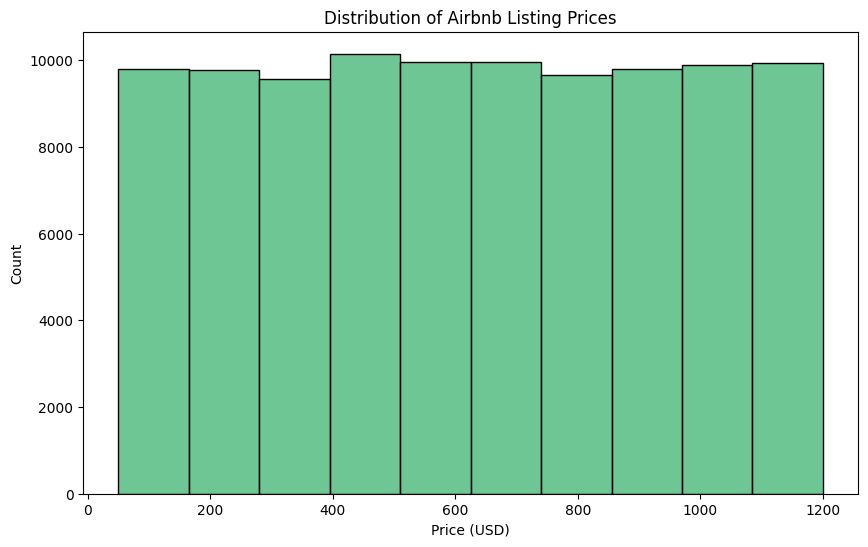

In [24]:
''' 1.  Analyse distribution of listing prices.
    * Identifies the typical price range.'''

plt.figure(figsize=(10, 6))

plt.title('Distribution of Airbnb Listing Prices')
plt.xlabel('Price (USD)')

sns.histplot(
    data=df,
    x='price',
    bins=10,
    color='mediumseagreen'
)

<Axes: title={'center': 'Count of Listings by Room Type'}, xlabel='Room Type', ylabel='Count'>

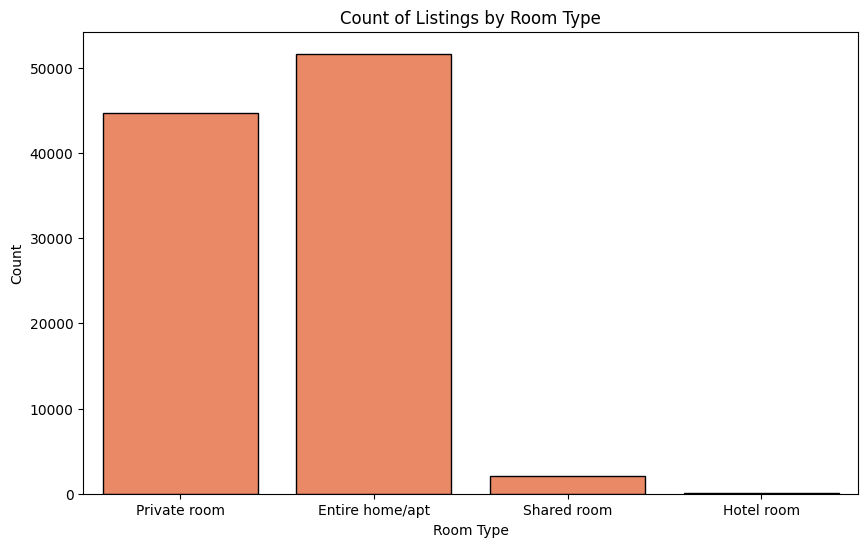

In [25]:
'''2. Visualize the count of listings for each room type.
    * Shows the market composition(which room type more available?).'''

plt.figure(figsize=(10, 6))

plt.title('Count of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')

sns.countplot(
    data=df,
    x='room_type',
    color='coral',
    edgecolor = 'black'
)

<Axes: title={'center': 'Number of Listings in Top 10 Popular Neighborhoods'}, xlabel='Count', ylabel='Neighborhoods'>

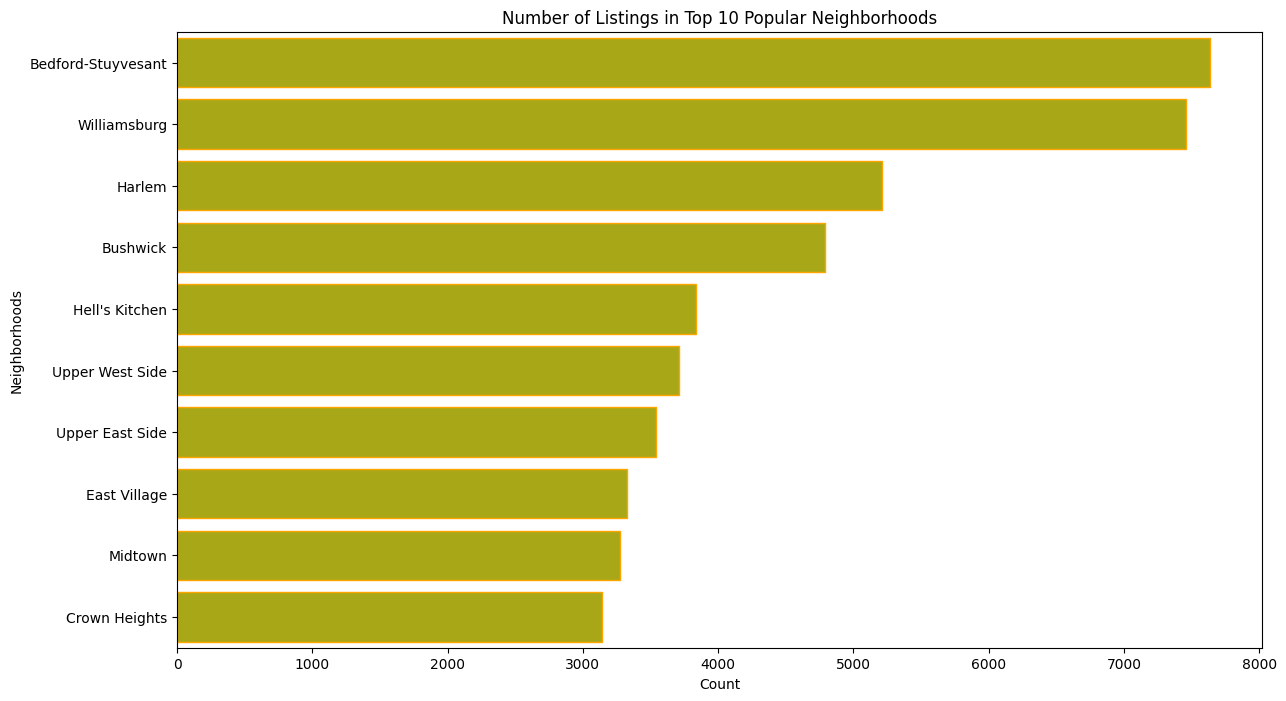

In [26]:
'''3. Show the number of listings in the most popular neighborhoods.
    * Highlights the high-density areas(where airbnbs are more located).'''

plt.figure(figsize=(14,8))

plt.title('Number of Listings in Top 10 Popular Neighborhoods')
plt.ylabel('Neighborhoods')
plt.xlabel('Count')

# considering only 10 largest neighbourhoods otherwise the plot will be conjusted
top_10_neighbourhoods = df['neighbourhood'].value_counts().nlargest(10).index

sns.countplot(
    data=df,
    y='neighbourhood',
    order=top_10_neighbourhoods,
    color='y',
    edgecolor= 'orange'
)

<Axes: title={'center': 'Price Distribution by Room Types'}, xlabel='Room Type', ylabel='Price (USD)'>

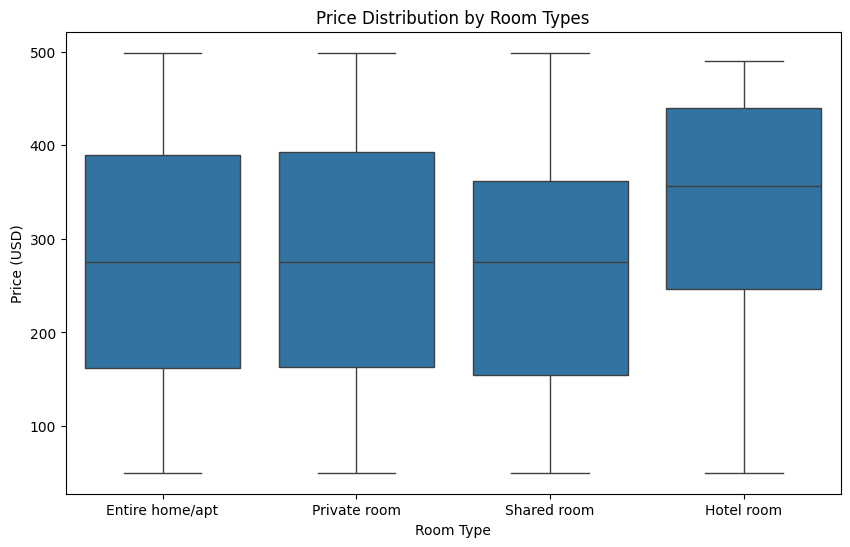

In [27]:
'''4. Compare the price distribution for different room types, showing the median and outliers.
    * Confirms that prices for "Entire home/apt" are typically higher and have greater variability.'''

plt.figure(figsize=(10, 6))

plt.title('Price Distribution by Room Types')
plt.xlabel('Room Type')
plt.ylabel('Price (USD)')

sns.boxplot(
    data=df[df['price']<500],
    x='room_type',
    y='price'
)

<Axes: title={'center': 'Average Price across Different Neighbourhoods'}, xlabel='Neighbourhood', ylabel='Price (USD)'>

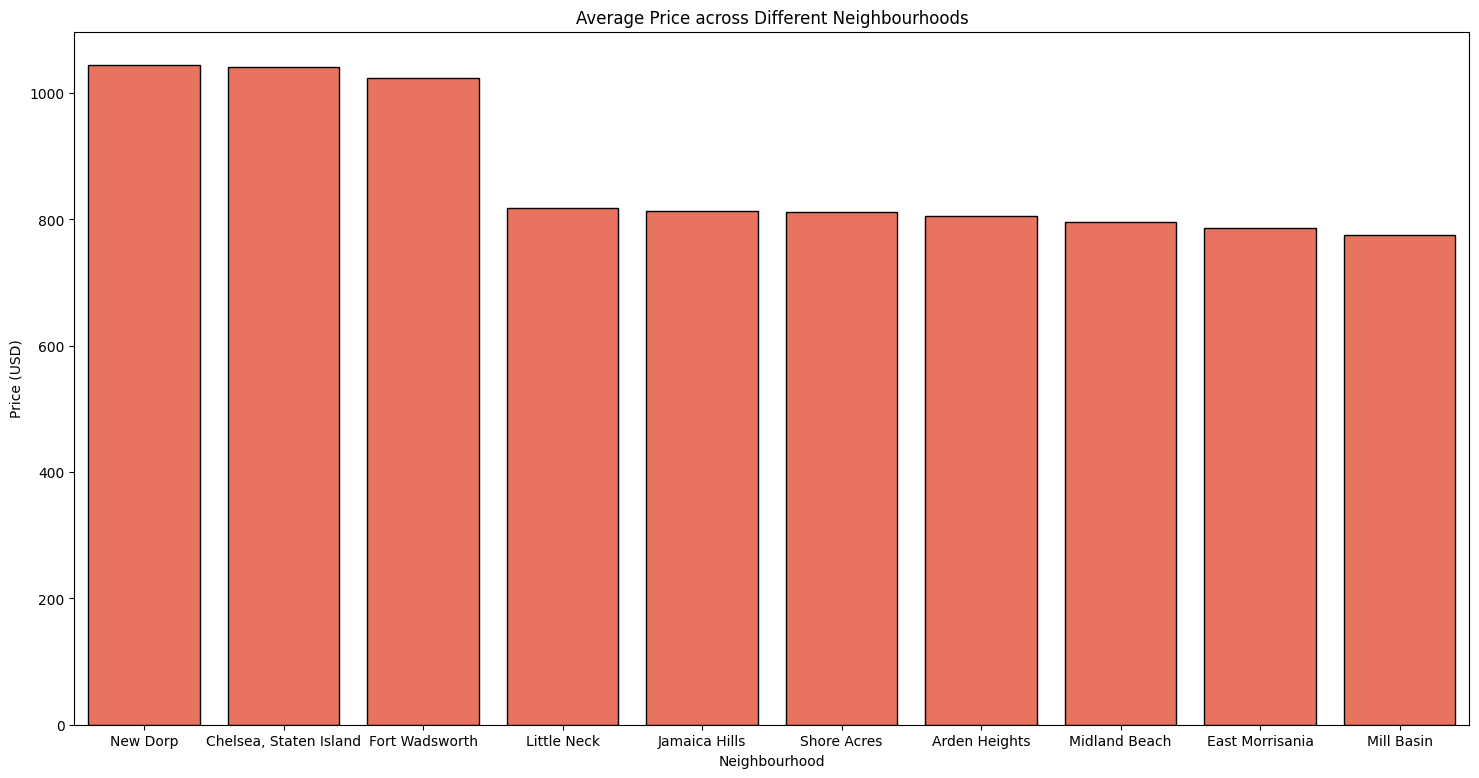

In [28]:
'''5. Compare the average price across different neighborhoods.
    * Identifies the most expensive and most affordable areas.'''

plt.figure(figsize=(18, 9))

plt.title('Average Price across Different Neighbourhoods')
plt.xlabel('Neighbourhood')
plt.ylabel('Price (USD)')

# grouping data based on neighbourhoods and calculating mean price range
# considering only 10 largest neighbourhoods otherwise the plot will be conjusted
avg_price_neighbourhoods = df.groupby(['neighbourhood'])['price'].mean().nlargest(10).reset_index()

sns.barplot(
    data=avg_price_neighbourhoods,
    x='neighbourhood',
    y='price',
    color='tomato',
    edgecolor = 'black'
)

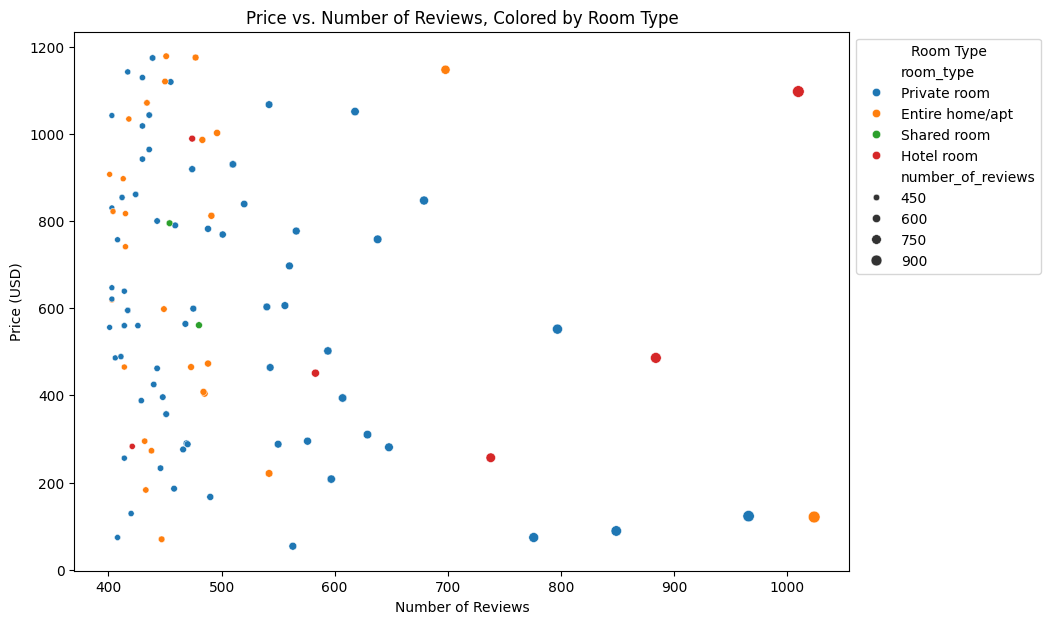

In [38]:
'''6. Explore the relationship between a listing's popularity (reviews) and its price.
    * Shows if highly-reviewed listings are generally priced higher, lower (due to competition), or if no clear relationship exists.'''

plt.figure(figsize=(10, 7))

plt.title('Price vs. Number of Reviews, Colored by Room Type')
plt.xlabel('Number of Reviews')
plt.ylabel('Price (USD)')

ax = sns.scatterplot(
    data=df[df['number_of_reviews']>400],
    x='number_of_reviews',
    y='price',
    hue='room_type',
    size='number_of_reviews'
)


plt.legend(title='Room Type')

# moving lengend box out of the plot
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

<Axes: title={'center': 'Correlation Matrix of Airbnb Numerical Features'}>

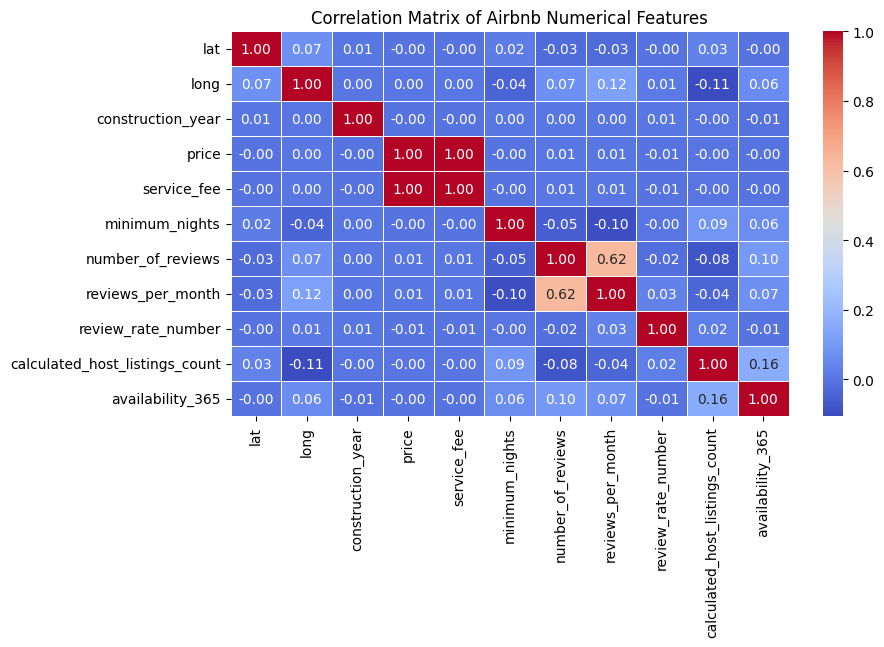

In [30]:
'''7. Visualize the correlation between all numerical variables.
    * Quickly identifies which numerical features (like price, minimum nights, and review counts) are strongly related.'''

plt.figure(figsize=(9, 5))

plt.title('Correlation Matrix of Airbnb Numerical Features')

# selecting all numerical columns to avoid wrrors with string columns
numerical_df = df.select_dtypes(include=np.number)

# creating a correlation matrix of numerical columns
correlation_matrix = numerical_df.corr()

sns.heatmap(
    correlation_matrix,annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5
)

<Axes: title={'center': 'Seasonality in Booking Activity'}, xlabel='Month', ylabel='Average Number of Reviews'>

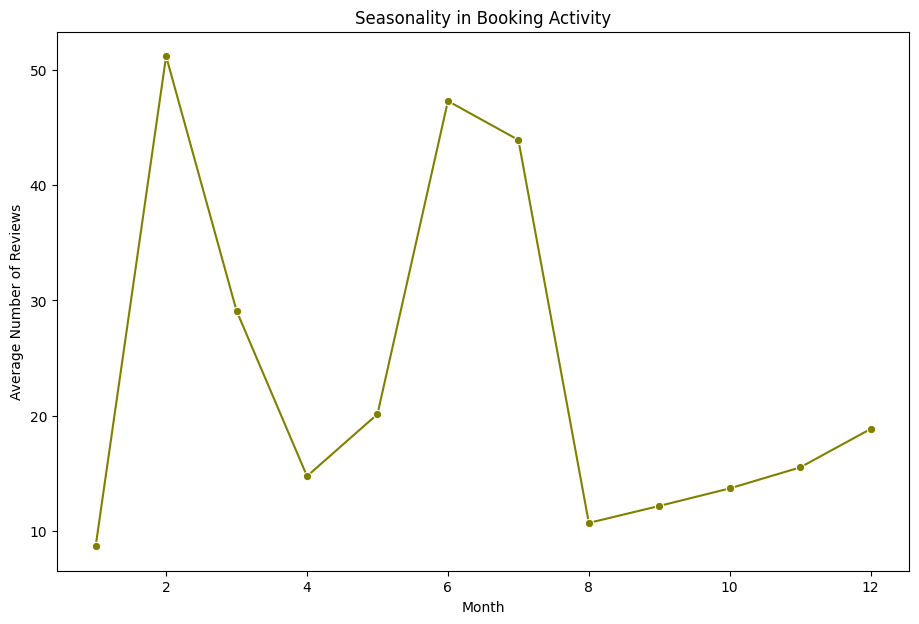

In [31]:
'''8. Analyze seasonality in booking activity.
    * Reveals the peak and off-peak seasons for Airbnb rentals.'''

plt.figure(figsize=(11, 7))

plt.title('Seasonality in Booking Activity')
plt.xlabel('Month')
plt.ylabel('Average Number of Reviews')

# grouping data based on month number and calculating mean number_of_reviews for each month 
month_wise_review = df.groupby(df['last_review'].dt.month)['number_of_reviews'].mean().reset_index()

sns.lineplot(
    data=month_wise_review,
    x='last_review',
    y='number_of_reviews',
    marker='o',
    color = 'olive'
)

<Axes: title={'center': 'Mean Minimum Nights Required by Room Type Across Different Neighbourhood Groups'}, xlabel='Room Type', ylabel='Average Minimum Nights'>

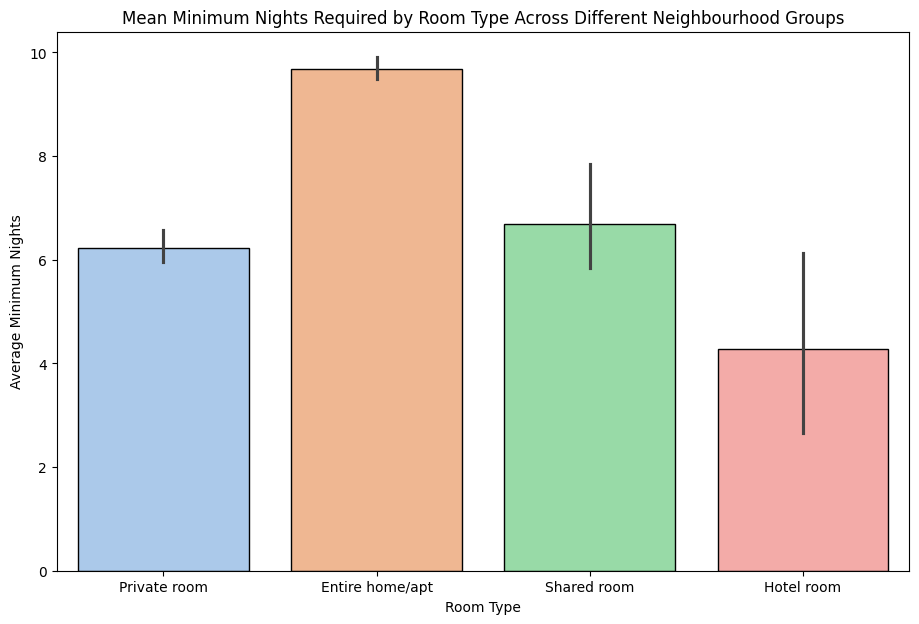

In [32]:
'''9. Is there any pattern in the minimum_nights requirement across room types?
    * eg : we find that "Entire home/apt" has a longer minimum stay.'''

plt.figure(figsize=(11, 7))

plt.title('Mean Minimum Nights Required by Room Type Across Different Neighbourhood Groups')
plt.ylabel('Average Minimum Nights')
plt.xlabel('Room Type')

sns.barplot(
    data=df, 
    x='room_type', 
    y='minimum_nights', 
    hue='room_type', 
    estimator='mean',
    palette='pastel',
    edgecolor = 'black'
)

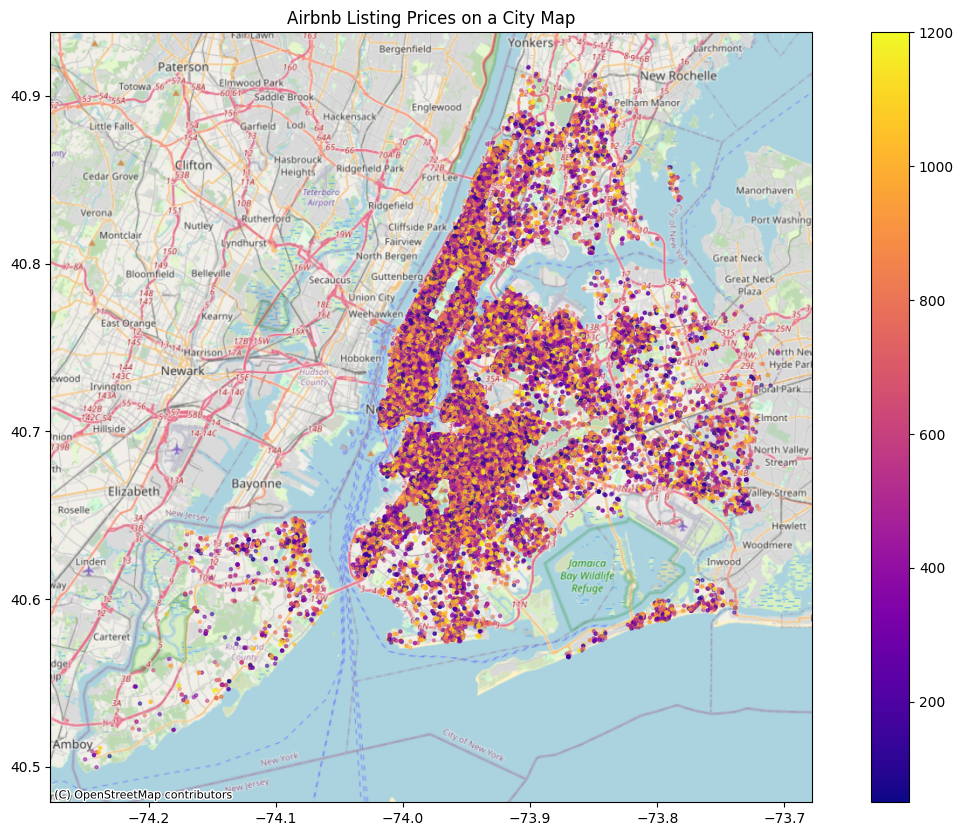

In [33]:
'''10. Map the density and distribution of listings.
    * Visually identifies clusters of expensive or popular listings.'''

# Created Point objects from latitude and longitude.
geometry = gpd.points_from_xy(df['long'], df['lat'])

# Create the GeoDataFrame, specifying the Coordinate Reference System (CRS)
# EPSG:4326 is standard for latitude/longitude data. This tells the software how to interpret the numbers in your geometry column.
gdf = gpd.GeoDataFrame(
    df.copy(), 
    geometry=geometry, 
    crs="EPSG:4326"
)

# --- Plotting the Data on a Map ---
plt.figure(figsize=(15, 10))
ax = gdf.plot(
    column='price', # Instructs to color the points based on value in price column
    cmap='plasma', 
    legend=True, 
    markersize=5, 
    alpha=0.5, # Transparency set to 50%
    ax=plt.gca()
)

plt.title('Airbnb Listing Prices on a City Map')

# Add the basemap (street map tiles)
# Convert CRS to Web Mercator (EPSG:3857) for Contextily to work
cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
# ax.set_axis_off() 

### **Data Analytics Final Project Report: Airbnb Listings Analysis**

#### **I. Problem Statement & Project Objectives**

##### **Problem Statement**
The short-term rental market is highly competitive and dynamic, making it difficult for hosts and prospective investors to determine optimal pricing strategies and identify high-value properties. This project aims to address this by performing comprehensive data analysis on Airbnb listing data to uncover key factors and trends influencing price, demand, and operational efficiency.

##### **Domain Selection Rationale**
I chose the Hospitality and Short-term Rentals domain, specifically using Airbnb data, to diversify my data analysis portfolio beyond my previous experience with sales and education datasets. This dataset provides a highly relevant, real-world scenario to practice complex cleaning (handling price strings and missing data), perform deep multivariate analysis, and execute geospatial visualization, ensuring a robust demonstration of end-to-end data analytics skills.

##### **Project Objectives**
1. Data Preparation Mastery
2. Comprehensive Exploratory Data Analysis (EDA)
3. Visualization and Insight Generation
4. Documentation and Presentation

#### **II. Data Description and Preparation Summary**
##### **Dataset Description**
This dataset comprises publicly available information about Airbnb listings and host activity in a specific geographic region. It contains details on listing properties (such as price, room type, and geographical coordinates), host characteristics, and guest engagement (including review counts and minimum night requirements). The data serves as a snapshot of the local short-term rental market, allowing for analysis of pricing strategies, demand, and operational trends.

##### **Data Cleaning and Pre-processing**
The raw dataset required extensive cleaning to ensure data integrity and usability:

**1. Duplicate Handling:**

All duplicate rows were identified and removed to ensure each listing was represented only once, maintaining data integrity.

**2. Column Standardization:**

Columns were renamed to a single, standard naming convention (e.g., lowercase with underscores) for improved consistency and ease of coding.

**3. Feature Reduction (Dropping Columns):**

Irrelevant columns, specifically id, host_id, license, and house_rules, were dropped to streamline the DataFrame and focus on core analytical features.

**4. Data Type Correction:**

The data types of several columns were corrected, most critically, converting the price and service_fee columns from string format (containing currency symbols) to a numeric (Float) type for mathematical operations.

**5. Missing Value (Low-Volume) Handling:**

Rows with negligible missing values (less than 1%) across key analytical columns (e.g., latitude, longitude, neighbourhood) were dropped. This preserved the overall dataset size while ensuring complete data for the most critical variables.

**6. Missing Value (High-Volume) Imputation:**

Null values in number_of_reviews were imputed with 0, reflecting the logical assumption that a missing value in this context means the listing has zero reviews.

Null values in last_review were imputed with a standard date value (01/01/1900). This preserved the rows for time-series analysis and clearly marked them as never having been reviewed.

#### **III. Key Insights and Findings**
Based on the EDA and visualization of the listings data, the following key insights were derived:

**1. Location is the Dominant Price Driver (Geospatial Analysis)**

Insight: The geospatial plot revealed a strong clustering of high-priced listings in specific, central neighborhoods, with prices rapidly decreasing as you move toward the periphery. This confirms that geographical location is the single most critical factor influencing a listing's price.

Supporting Visuals: Geospatial Plot of Listings (color-coded by price) and Bar Plot of Average Price per Neighbourhood.

**2. Entire Home/Apts are the Market Standard, but Not the Price Leader**

Insight: The count plot showed that 'Entire home/apt' listings make up the largest percentage of the market supply, confirming the market is dominated by full property rentals rather than shared spaces. However, the analysis found that 'Hotel rooms' often command the highest average price, likely due to offering guaranteed quality and professional services.

Supporting Visuals: Bar Chart of Room Types and Box Plot of Average Price per Room Type.

**3. High Demand is Concentrated and Predictable**

Insight: The analysis of reviews_per_month and time-series data revealed that demand, proxied by review activity, is highly seasonal and spatially uneven. High-demand listings are not necessarily the cheapest, suggesting guests are willing to pay a premium for properties with high review volume.

Supporting Visuals: Line Chart of Reviews per Month over Time and Scatter Plot of Price vs. Number of Reviews.

**4. Longer Stays are Common for Full Properties**

Insight: The Bar Plot of Minimum Nights by Room Type showed a clear operational pattern: 'Entire home/apt' listings have a significantly higher average minimum night requirement compared to 'Private room' or 'Shared room' listings. This suggests hosts are optimizing these higher-value properties for revenue stability and lower turnover costs.

Supporting Visuals: Bar Plot of Mean Minimum Nights by Room Type and Neighborhood Group.

**5. Large-Scale Hosts Dominate Inventory but Not Necessarily Price**

Insight: A small percentage of "Super Hosts" or large-scale operators (those with a high calculated_host_listings_count) collectively own a disproportionately large share of the listings. While they control the inventory, their pricing strategy often aims for high occupancy (high turnover), resulting in their average prices being competitive rather than always maximizing the top-tier prices.

Supporting Visuals: Bar Plot of Top Hosts by Listing Count and analysis of mean price vs. host count.

#### **IV. Conclusion and Recommendations**
##### **Conclusion**
The project successfully cleaned and analyzed the complex Airbnb dataset, highlighting that Location, Room Type, and Host Strategy are the primary determinants of success in the short-term rental market. The findings provide concrete, data-backed guidance for market participants.

##### **Potential Recommendations (Next Steps)**
These recommendations are targeted at new hosts or investors looking to maximize their return:

**Price Dynamically with Location Focus:** Do not rely on a flat seasonal pricing model. Use the geospatial analysis to set a premium base price relative to your specific neighborhood and then use demand proxies (like local event calendars) to adjust rates, maximizing the Average Daily Rate (ADR) during peak times.

**Optimize Operational Constraints:** If listing an 'Entire home/apt', set the minimum night requirement higher than the average for private rooms to reduce turnover costs and stabilize revenue, as demand for longer stays exists for full properties.

**Target Amenities:** Conduct deeper analysis on amenities to identify features that correlate with a price premium (e.g., dedicated workspace, high-speed Wi-Fi) and invest in those to justify a higher rate.